In [8]:
#Imports
import pandas as pd
import string
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
from kmodes import KModes

In [9]:
#Import Data

og_df = pd.read_csv("../data/dataset-tickets-multi-lang-4-20k.csv")
og_df.info()
og_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   18539 non-null  object
 1   body      19998 non-null  object
 2   answer    19996 non-null  object
 3   type      20000 non-null  object
 4   queue     20000 non-null  object
 5   priority  20000 non-null  object
 6   language  20000 non-null  object
 7   tag_1     20000 non-null  object
 8   tag_2     19954 non-null  object
 9   tag_3     19905 non-null  object
 10  tag_4     18461 non-null  object
 11  tag_5     13091 non-null  object
 12  tag_6     7351 non-null   object
 13  tag_7     3928 non-null   object
 14  tag_8     1907 non-null   object
dtypes: object(15)
memory usage: 2.3+ MB


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


### Clean and Preprocess Data

In [10]:
#Remove tickets not in english
df = og_df[og_df['language']=="en"]
df = df.drop(columns='language')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 11923 entries, 1 to 19997
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   10891 non-null  object
 1   body      11922 non-null  object
 2   answer    11920 non-null  object
 3   type      11923 non-null  object
 4   queue     11923 non-null  object
 5   priority  11923 non-null  object
 6   tag_1     11923 non-null  object
 7   tag_2     11913 non-null  object
 8   tag_3     11879 non-null  object
 9   tag_4     11050 non-null  object
 10  tag_5     7885 non-null   object
 11  tag_6     4538 non-null   object
 12  tag_7     2565 non-null   object
 13  tag_8     1327 non-null   object
dtypes: object(14)
memory usage: 1.4+ MB


,subject,body,answer,type,queue,priority,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN
5,Concerns About Securing Medical Data on 2-in-1...,Inquiring about best practices for securing me...,Thank you for your concern regarding securing ...,Request,Technical Support,medium,Security,Product,Feature,IT,Tech Support,NaN,NaN,NaN
7,Problem with Integration,"The integration stopped working unexpectedly, ...",I will look into the problem and call you at <...,Problem,IT Support,high,Technical,Integration,Bug,Resolution,Outage,Documentation,NaN,NaN


In [11]:
# df.isnull().sum()
df = df.drop(columns=['tag_6', 'tag_7', 'tag_8'])
df.isnull().sum()

subject     1032
body           1
answer         3
type           0
queue          0
priority       0
tag_1          0
tag_2         10
tag_3         44
tag_4        873
tag_5       4038
dtype: int64

In [12]:
df = df.dropna(subset=['body', 'answer'])
tag_columns = ['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5']
df[tag_columns] = df[tag_columns].fillna('Unknown')
df = df.drop(columns='subject')
df.isnull().sum()

body        0
answer      0
type        0
queue       0
priority    0
tag_1       0
tag_2       0
tag_3       0
tag_4       0
tag_5       0
dtype: int64

In [13]:
#Check for weird values
for col in df:
    num_unique = df[col].nunique()
    print(col, num_unique)

print(df['type'].unique())
print(df['queue'].unique())
print(df['priority'].unique())

body 11919
answer 11919
type 4
queue 10
priority 3
tag_1 87
tag_2 177
tag_3 298
tag_4 401
tag_5 478
['Request' 'Problem' 'Incident' 'Change']
['Customer Service' 'Technical Support' 'IT Support' 'Product Support'
 'Billing and Payments' 'Service Outages and Maintenance'
 'Human Resources' 'Returns and Exchanges' 'Sales and Pre-Sales'
 'General Inquiry']
['medium' 'high' 'low']


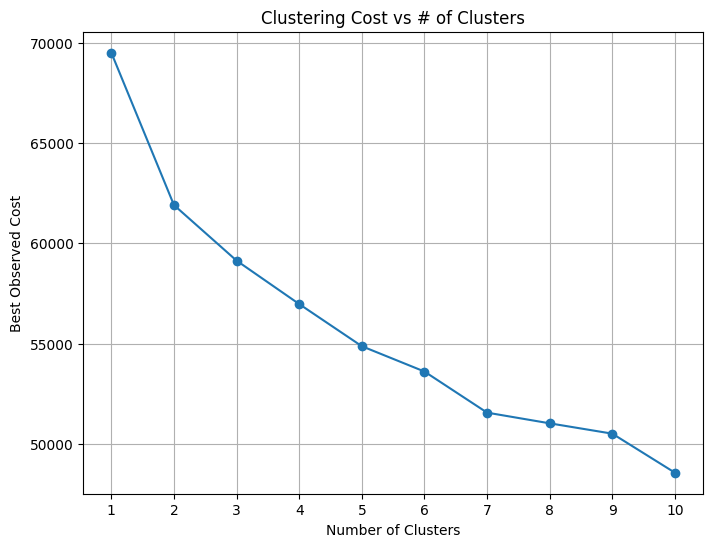

In [14]:
clustering_df = df.drop(columns=['body', 'answer'])
results = []
for k in range(1,11):
    costs = []
    for _ in range(10):
        kmode = KModes(k, clustering_df)
        costs.append(kmode.get_cost())

    results.append(min(costs))

    
k_values = list(range(1, 11))
plt.figure(figsize=(8, 6))
plt.plot(k_values, results, marker='o', linestyle='-')


plt.xlabel("Number of Clusters")
plt.ylabel("Best Observed Cost")
plt.title("Clustering Cost vs # of Clusters")
plt.xticks(k_values)  
plt.grid(True)
plt.show()

#seems like 8 clusters is the way to go

In [15]:
import numpy as np
best_cost = np.inf

for _ in range(10):
    kmode = KModes(6, clustering_df)
    cost = kmode.get_cost()
    if cost < best_cost:
        best_cost = cost
        clusters = kmode.get_clusters()

In [16]:
cluster_data =[]
for clust in clusters:
    cluster_data.append(clust.get_data())

cluster_data[0].head()

,0,1,2,3,4,5,6,7
109,Incident,Product Support,high,Technical,Customer,Integration,Metrics,QuickBooks
5,Problem,Technical Support,high,Technical,Outage,Crash,Resolution,Disruption
6,Incident,Technical Support,high,Technical,Bug,DataLoss,SoftwareUpdate,SyncIssue
8,Incident,Technical Support,low,Technical,Bug,API,Documentation,Resolution
13,Incident,Customer Service,high,Breach,Security,Incident,Resolution,Investigation


In [17]:
tag_cols = ['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5']

for i, cluster_df in enumerate(cluster_data):
    print(f"\n--- Cluster {i} Tag Counts ---")
    for tag in range(len(tag_cols)):
        print(f"\n{tag} value counts:")
        print(cluster_df.iloc[:,tag].value_counts())


--- Cluster 0 Tag Counts ---

0 value counts:
0
Incident    1780
Problem      605
Change       200
Request      142
Name: count, dtype: int64

1 value counts:
1
Technical Support                  1388
Product Support                     373
IT Support                          323
Billing and Payments                205
Service Outages and Maintenance     178
Returns and Exchanges                94
Customer Service                     67
General Inquiry                      38
Sales and Pre-Sales                  38
Human Resources                      23
Name: count, dtype: int64

2 value counts:
2
high      1727
low        503
medium     497
Name: count, dtype: int64

3 value counts:
3
Technical                                              1589
Security                                                246
Crash                                                   227
Billing                                                 168
Outage                                                   99
Per